<a href="https://colab.research.google.com/github/Adj95/python_dsc/blob/main/polynomial_regression.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [43]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression , SGDRegressor
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.metrics import  r2_score
from sklearn.pipeline import Pipeline

In [44]:
x = 6 * np.random.rand(200,1) - 3
y = 0.8 * x**2  + 0.9 * x + 2 +np.random.rand(200 , 1)

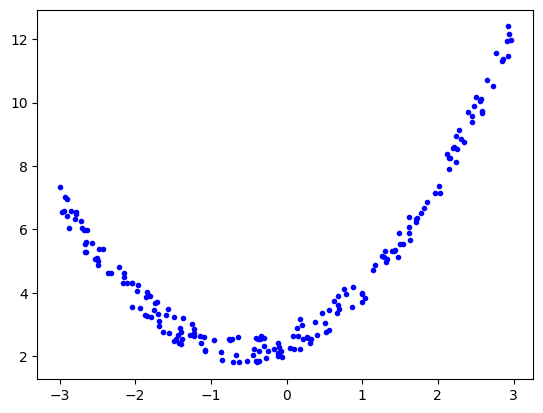

In [45]:
plt.plot(x,y,'b.')

In [46]:
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.2,random_state=42)

In [47]:
poly = PolynomialFeatures(degree = 2)
x_train_trf = poly.fit_transform(x_train)
x_test_trf = poly.transform(x_test)

In [48]:
lr = LinearRegression()
lr.fit(x_train_trf,y_train)

LinearRegression()

In [49]:
pred = lr.predict(x_test_trf)

In [50]:
r2_score(y_test,pred)

0.989303455217687

In [51]:
x_new =np.linspace(-3,3,200).reshape(200,1)
x_new_trf = poly.transform(x_new)
y_new = lr.predict(x_new_trf)

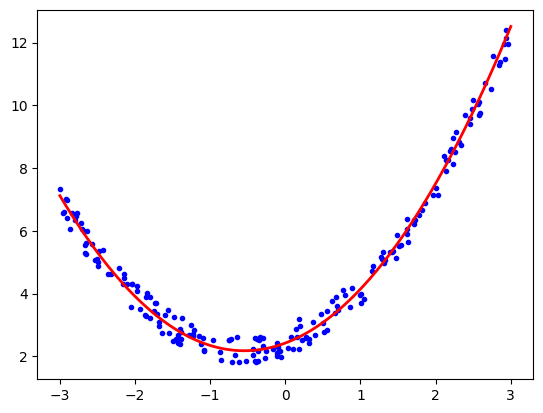

In [52]:
plt.plot(x_train , y_train , "b." , label = 'training points')
plt.plot(x_test , y_test , "b." , label = 'testing  points')
plt.plot(x_new,y_new , "r-" , linewidth = 2 ,label = 'predictions')

In [53]:
# 3D polynomial regression
x = 7 * np.random.rand(100, 1) - 2.8
y = 7 * np.random.rand(100, 1) - 2.8

z = x**2 + y**2 + 0.2*x + 0.2*y + 0.1*x*y +2 + np.random.randn(100, 1)
# z = x^2 + y^2 + 0.2x + 0.2y + 0.1xy + 2

In [54]:
import plotly.express as px
df = px.data.iris()
fig = px.scatter_3d(df, x=x.ravel(), y=y.ravel(), z=z.ravel())
fig.show()


In [55]:
lr = LinearRegression()
lr.fit(np.array([x,y]).reshape(100,2),z)

x_input = np.linspace(x.min(), x.max(), 10)
y_input = np.linspace(y.min(), y.max(), 10)
xGrid, yGrid = np.meshgrid(x_input,y_input)

final = np.vstack((xGrid.ravel().reshape(1,100),yGrid.ravel().reshape(1,100))).T

z_final = lr.predict(final).reshape(10,10)

In [56]:
import plotly.graph_objects as go

fig = px.scatter_3d(df, x=x.ravel(), y=y.ravel(), z=z.ravel())

fig.add_trace(go.Surface(x = x_input, y = y_input, z =z_final ))

fig.show()

In [57]:
X_multi = np.array([x,y]).reshape(100,2)
X_multi.shape

(100, 2)

In [58]:
poly = PolynomialFeatures(degree=3)
X_multi_trans = poly.fit_transform(X_multi)

In [59]:
print("Input",poly.n_features_in_)
print("Ouput",poly.n_output_features_)
print("Powers\n",poly.powers_)

Input 2
Ouput 10
Powers
 [[0 0]
 [1 0]
 [0 1]
 [2 0]
 [1 1]
 [0 2]
 [3 0]
 [2 1]
 [1 2]
 [0 3]]


In [60]:
lr = LinearRegression()
lr.fit(X_multi_trans,z)

LinearRegression()

In [61]:
X_test_multi = poly.transform(final)
z_final = lr.predict(X_multi_trans).reshape(10,10)

In [62]:
fig = px.scatter_3d(x=x.ravel(), y=y.ravel(), z=z.ravel())

fig.add_trace(go.Surface(x = x_input, y = y_input, z =z_final))

fig.update_layout(scene = dict(zaxis = dict(range=[0,35])))

fig.show()